# Głębokie Uczenie w Praktyce
## Laboratorium 9
### Mateusz Horczak

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255.0

#### Ćwiczenie 1. Zaimplementuj wariancyjny autoenkoder (VAE)

In [7]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3136)      │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │     50,192 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

history = vae.fit(mnist_digits, epochs=30, batch_size=128)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - kl_loss: 3.8956 - loss: 208.0685 - reconstruction_loss: 204.1729
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 5.8579 - loss: 173.2369 - reconstruction_loss: 167.3789
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.0724 - loss: 164.9107 - reconstruction_loss: 158.8383
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.2386 - loss: 161.6320 - reconstruction_loss: 155.3934
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 6.3185 - loss: 159.7927 - reconstruction_loss: 153.4742
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 6.3676 - loss: 158.2979 - reconstruction_loss: 151.9303
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.3999 - loss: 157.1626 - reconstruction_loss: 150.7627
Epoch 8/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - kl_loss: 6.4459 - loss: 156.2820 - reconstruction_loss: 149.8361
Epoch 9/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 

#### Ćwiczenie 2. Generowanie obrazów z latent space

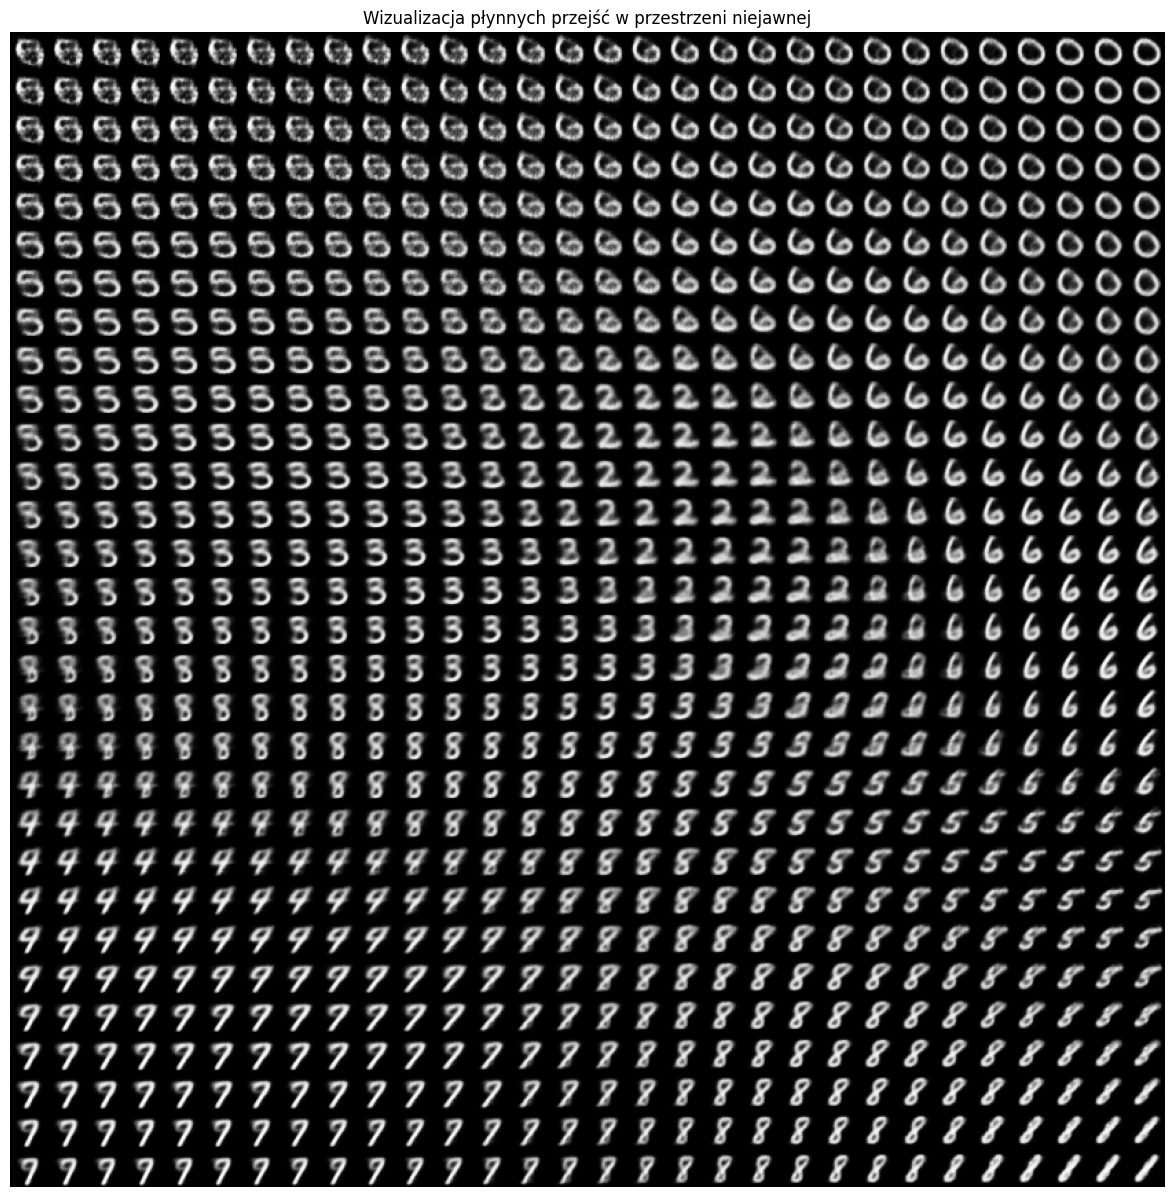

Generowanie 3 losowych cyfr:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


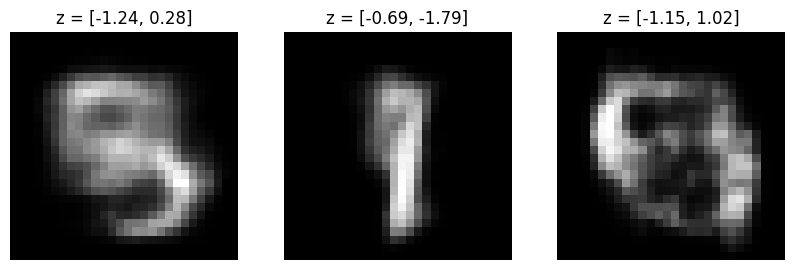

In [10]:
def plot_latent_space(vae, n=30, figsize=15):
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n))
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="Greys_r")
    plt.title("Wizualizacja płynnych przejść w przestrzeni niejawnej")
    plt.axis("off")
    plt.show()

plot_latent_space(vae)

print("Generowanie 3 losowych cyfr:")
losowe_z = np.random.normal(size=(3, 2))
x_decoded = vae.decoder.predict(losowe_z)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i in range(3):
    axes[i].imshow(x_decoded[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"z = [{losowe_z[i][0]:.2f}, {losowe_z[i][1]:.2f}]")
plt.show()

#### Ćwiczenie 3. Wizualizacja latent space

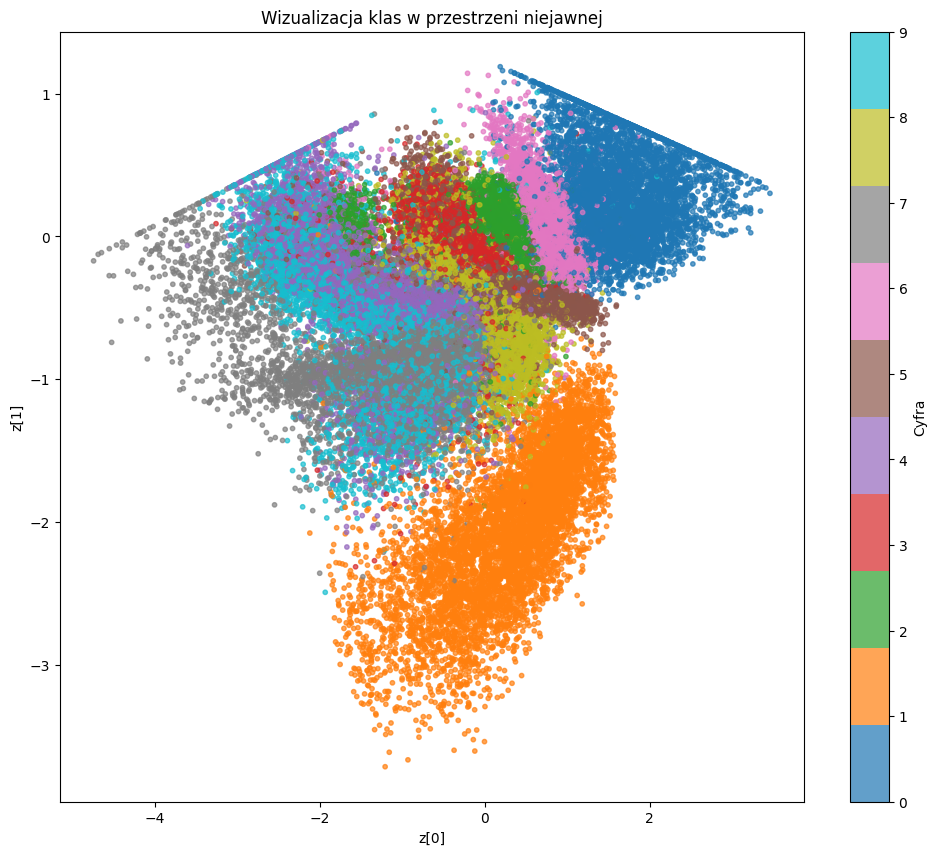

In [11]:
def plot_label_clusters(vae, data, labels):
    z_mean, _, _ = vae.encoder.predict(data, verbose=0)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap='tab10', alpha=0.7, s=10)
    plt.colorbar(label='Cyfra')
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("Wizualizacja klas w przestrzeni niejawnej")
    plt.show()

x_train_norm = np.expand_dims(x_train, -1).astype("float32") / 255.0
plot_label_clusters(vae, x_train_norm, y_train)

#### Ćwiczenie 4. Zaprezentuj krzywe straty na przestrzeni epok

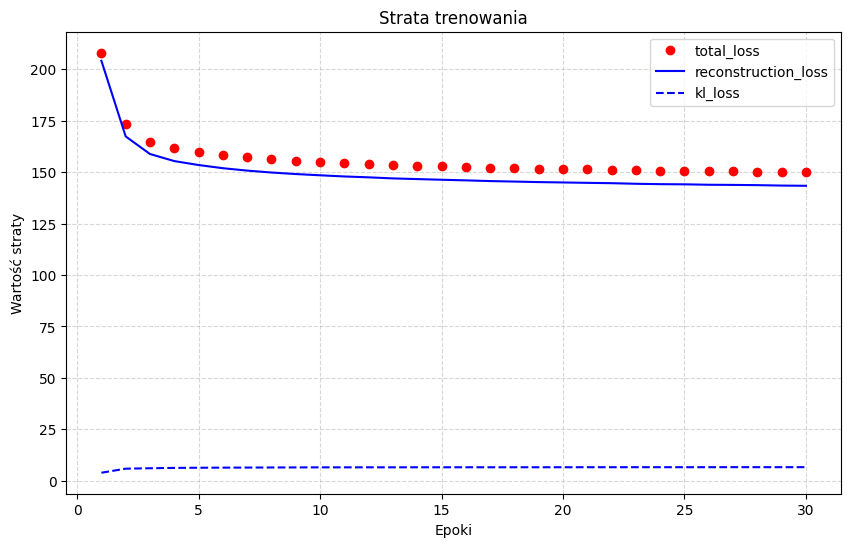

In [13]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)
loss = history.history['loss']
reconstruction_loss = history.history['reconstruction_loss']
kl_loss = history.history['kl_loss']

plt.figure(figsize=(10, 6))

plt.plot(epochs, loss, 'ro', label='total_loss')

plt.plot(epochs, reconstruction_loss, 'b-', label='reconstruction_loss')
plt.plot(epochs, kl_loss, 'b--', label='kl_loss')

plt.title('Strata trenowania')
plt.xlabel('Epoki')
plt.ylabel('Wartość straty')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Ćwiczenie 5. Zmodyfikuj pętlę trenowania VAE (trenuj 1 epoką w pętli)


--- Epoka 1/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 3.2491 - loss: 209.7171 - reconstruction_loss: 206.4680
Latent Space -> Średnia: 0.4278, Odchylenie std: 1.5864

--- Epoka 2/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 5.7103 - loss: 171.1626 - reconstruction_loss: 165.4523
Latent Space -> Średnia: 0.4099, Odchylenie std: 1.1695


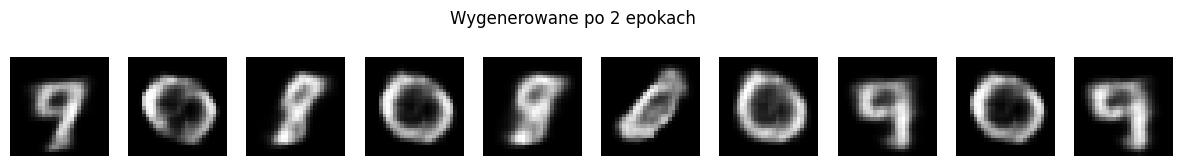


--- Epoka 3/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 6.0192 - loss: 163.9288 - reconstruction_loss: 157.9097
Latent Space -> Średnia: 0.3227, Odchylenie std: 1.1169

--- Epoka 4/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.1781 - loss: 160.8411 - reconstruction_loss: 154.6630
Latent Space -> Średnia: 0.3569, Odchylenie std: 1.0731


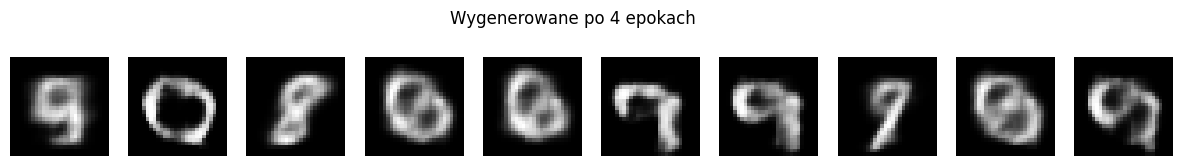


--- Epoka 5/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.2814 - loss: 158.9069 - reconstruction_loss: 152.6255
Latent Space -> Średnia: 0.3150, Odchylenie std: 1.0611

--- Epoka 6/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 6.3554 - loss: 157.5221 - reconstruction_loss: 151.1666
Latent Space -> Średnia: 0.3017, Odchylenie std: 1.0724


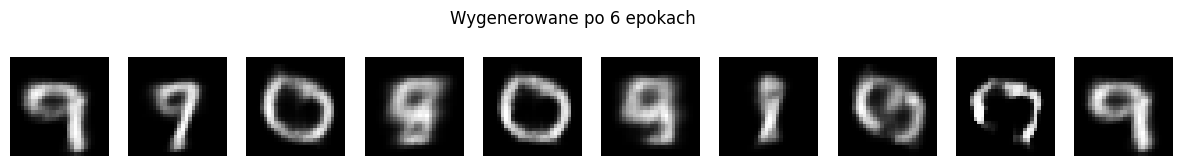


--- Epoka 7/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - kl_loss: 6.4113 - loss: 156.4818 - reconstruction_loss: 150.0705
Latent Space -> Średnia: 0.2623, Odchylenie std: 1.0585

--- Epoka 8/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 6.4677 - loss: 155.4956 - reconstruction_loss: 149.0278
Latent Space -> Średnia: 0.2775, Odchylenie std: 1.0256


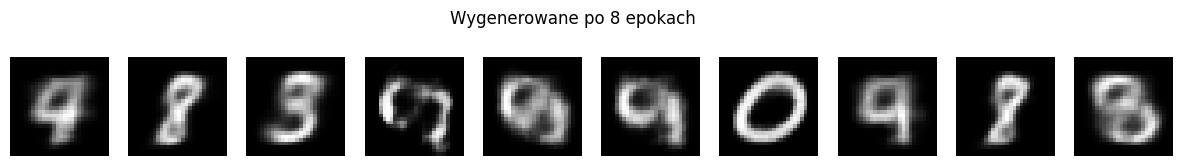


--- Epoka 9/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 6.4721 - loss: 154.8223 - reconstruction_loss: 148.3503
Latent Space -> Średnia: 0.2852, Odchylenie std: 1.0302

--- Epoka 10/10 ---
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 6.5262 - loss: 154.2403 - reconstruction_loss: 147.7140
Latent Space -> Średnia: 0.2815, Odchylenie std: 1.0263


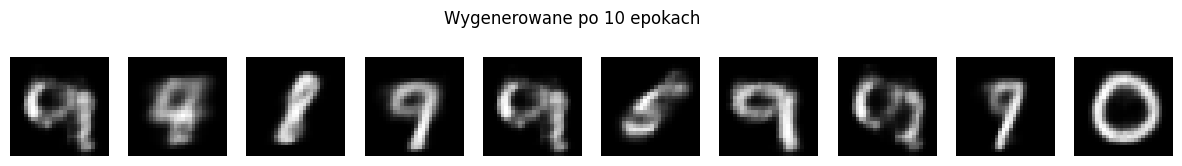

In [14]:
encoder2 = keras.models.clone_model(encoder)
decoder2 = keras.models.clone_model(decoder)
vae_custom = VAE(encoder2, decoder2)
vae_custom.compile(optimizer=keras.optimizers.Adam())

EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\n--- Epoka {epoch + 1}/{EPOCHS} ---")
    vae_custom.fit(mnist_digits, epochs=1, batch_size=128)

    z_mean, z_log_var, z = vae_custom.encoder.predict(mnist_digits[:1000], verbose=0)
    print(f"Latent Space -> Średnia: {np.mean(z):.4f}, Odchylenie std: {np.std(z):.4f}")

    if (epoch + 1) % 2 == 0:
        losowe_z = np.random.normal(size=(10, 2))
        wygenerowane = vae_custom.decoder.predict(losowe_z, verbose=0)

        fig, axes = plt.subplots(1, 10, figsize=(15, 2))
        for i in range(10):
            axes[i].imshow(wygenerowane[i].reshape(28, 28), cmap='gray')
            axes[i].axis('off')
        plt.suptitle(f"Wygenerowane po {epoch+1} epokach")
        plt.show()

#### Ćwiczenie 6. Przeprowadź eksperymenty na VAE

In [15]:
class BetaVAE(VAE):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(BetaVAE, self).__init__(encoder, decoder, **kwargs)
        self.beta = beta # Zmienna Beta

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + (self.beta * kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

(x_train_fashion, y_train_fashion), (x_test_fashion, _) = keras.datasets.fashion_mnist.load_data()

fashion_digits = np.concatenate([x_train_fashion, x_test_fashion], axis=0)
fashion_digits = np.expand_dims(fashion_digits, -1).astype("float32") / 255.0

print("Kształt danych Fashion MNIST:", fashion_digits.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Kształt danych Fashion MNIST: (70000, 28, 28, 1)



Trenowanie BetaVAE z wartością Beta = 0.2
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - kl_loss: 20.0442 - loss: 323.0163 - reconstruction_loss: 319.0075
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 17.0245 - loss: 277.3548 - reconstruction_loss: 273.9499
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 13.7983 - loss: 271.0771 - reconstruction_loss: 268.3175


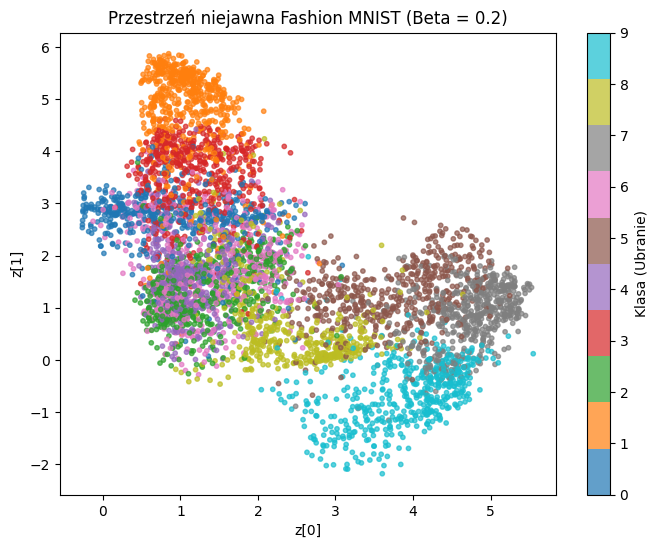


Trenowanie BetaVAE z wartością Beta = 1.0
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 5.8249 - loss: 312.2953 - reconstruction_loss: 306.4703
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 5.7908 - loss: 273.8681 - reconstruction_loss: 268.0772
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 5.9033 - loss: 270.6659 - reconstruction_loss: 264.7628


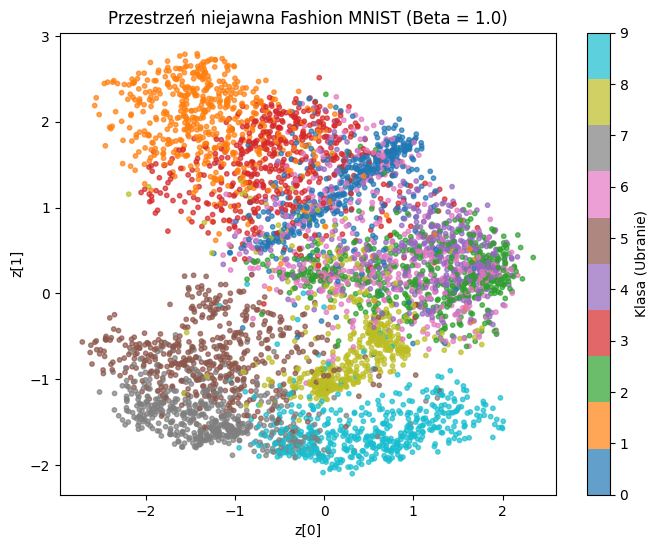


Trenowanie BetaVAE z wartością Beta = 2.0
Epoch 1/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - kl_loss: 3.9893 - loss: 334.9082 - reconstruction_loss: 326.9296
Epoch 2/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 4.5480 - loss: 282.5865 - reconstruction_loss: 273.4905
Epoch 3/3
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 4.9703 - loss: 273.7889 - reconstruction_loss: 263.8486


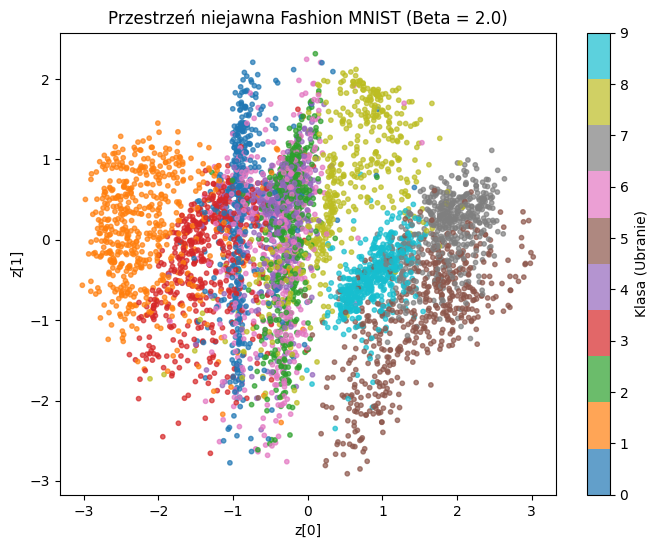

In [16]:
beta_values = [0.2, 1.0, 2.0]

for b in beta_values:
    print(f"\n=========================================")
    print(f"Trenowanie BetaVAE z wartością Beta = {b}")
    print(f"=========================================")

    enc_exp = keras.models.clone_model(encoder)
    dec_exp = keras.models.clone_model(decoder)

    beta_vae = BetaVAE(enc_exp, dec_exp, beta=b)
    beta_vae.compile(optimizer=keras.optimizers.Adam())

    beta_vae.fit(fashion_digits, epochs=3, batch_size=128)

    z_mean_exp, _, _ = beta_vae.encoder.predict(fashion_digits[:5000], verbose=0)

    plt.figure(figsize=(8, 6))
    plt.scatter(z_mean_exp[:, 0], z_mean_exp[:, 1], c=y_train_fashion[:5000], cmap='tab10', alpha=0.7, s=10)
    plt.colorbar(label='Klasa (Ubranie)')
    plt.title(f"Przestrzeń niejawna Fashion MNIST (Beta = {b})")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()